In [1]:
import sys
sys.path.append('/Users/kellyhui/koskella_lab_notebook')
from tools import *

In [12]:
df = pd.read_csv('/Users/kellyhui/Downloads/RBG_data/KH_RBG_02082026.csv')
df = clean_and_transpose(df, 32, 118)
df1 = df.copy()
df

Series,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,...,G3,G4,G5,G6,G7,G8,G9,G10,G11,G12
Time [s],,,,,,,,,,,,,,,,,,,,,
0.000000,0.1906,0.1831,0.2209,0.1995,0.1972,0.2047,0.2150,0.1973,0.2060,0.2095,...,0.1043,0.1018,0.1023,0.1015,0.1055,0.1265,0.1024,0.1414,0.1122,0.1041
0.250028,0.1890,0.1869,0.2040,0.1865,0.1848,0.1974,0.2064,0.1892,0.2004,0.1994,...,0.1025,0.1012,0.1010,0.1012,0.1008,0.1013,0.1016,0.1025,0.1045,0.1036
0.500056,0.1919,0.1878,0.1892,0.1913,0.1884,0.2005,0.2096,0.1903,0.2027,0.2052,...,0.1023,0.1010,0.1008,0.1010,0.1006,0.1011,0.1014,0.1022,0.1037,0.1033
0.750083,0.1952,0.1906,0.1912,0.1985,0.1921,0.2067,0.2125,0.1925,0.2033,0.2086,...,0.1018,0.1002,0.1002,0.1003,0.0998,0.1004,0.1007,0.1025,0.1027,0.1026
1.000111,0.1949,0.1925,0.1927,0.2022,0.1950,0.2079,0.2143,0.1883,0.2040,0.2078,...,0.1020,0.1004,0.1004,0.1005,0.1000,0.1006,0.1009,0.1028,0.1029,0.1029
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34.753333,0.2752,0.2585,0.2533,0.2565,0.2224,0.2739,0.2605,0.2574,0.2897,0.2711,...,0.1009,0.1068,0.0994,0.0993,0.0989,0.0990,0.0997,0.1013,0.1019,0.1012
35.003361,0.2758,0.2584,0.2532,0.2556,0.2221,0.2742,0.2602,0.2580,0.2905,0.2711,...,0.1008,0.1063,0.0991,0.0991,0.0986,0.0988,0.0993,0.1011,0.1016,0.1009
35.253389,0.2768,0.2586,0.2532,0.2561,0.2223,0.2743,0.2608,0.2584,0.2905,0.2712,...,0.1010,0.1065,0.0993,0.0993,0.0990,0.0991,0.0997,0.1013,0.1021,0.1013


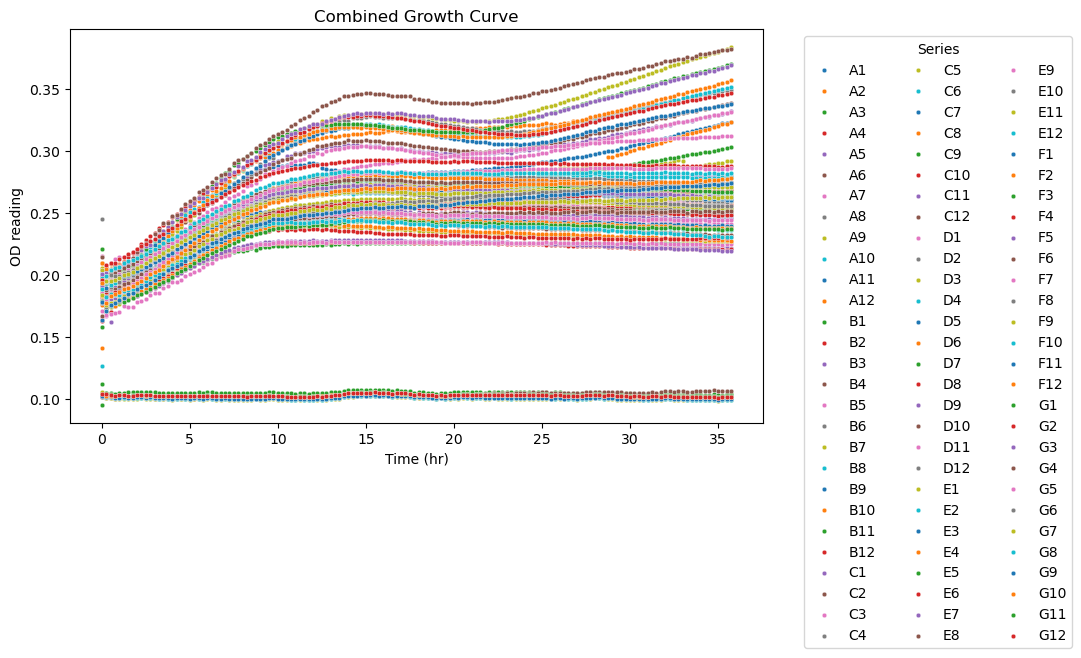

In [13]:
plot_timeseries(df, 'Combined Growth Curve')

In [20]:
def plot_biol_rep(df, num_bio_rep=8, col_num=3): 
    letters = list(string.ascii_uppercase[:num_bio_rep])

    for letter in letters:
        # Select columns that begin with this letter (e.g., "A")
        table = df.filter(regex=rf'^{letter}')

        if table.empty:
            print(f"Warning: No columns found for replicate {letter}")
            continue
        
        table_avg = table.groupby(np.arange(table.shape[1]) // col_num, axis=1).mean()
        print(table_avg)
        
        plot_timeseries(table_avg, title=f'Biological Replicate - {letter}')

In [26]:
df[['A10', 'A11', 'A12']] #internal variability looks consistent

Series,A10,A11,A12
Time [s],,,
0.000000,0.2095,0.2006,0.2093
0.250028,0.1994,0.1950,0.2066
0.500056,0.2052,0.1987,0.2085
0.750083,0.2086,0.2015,0.2078
1.000111,0.2078,0.2030,0.2087
...,...,...,...
34.753333,0.2711,0.3203,0.3192
35.003361,0.2711,0.3212,0.3199
35.253389,0.2712,0.3223,0.3217


                  0         1         2         3
Time [s]                                         
0.000000   0.198200  0.200467  0.206100  0.206467
0.250028   0.193300  0.189567  0.198667  0.200333
0.500056   0.189633  0.193400  0.200867  0.204133
0.750083   0.192333  0.199100  0.202767  0.205967
1.000111   0.193367  0.201700  0.202200  0.206500
...             ...       ...       ...       ...
34.753333  0.262333  0.250933  0.269200  0.303533
35.003361  0.262467  0.250633  0.269567  0.304067
35.253389  0.262867  0.250900  0.269900  0.305067
35.503417  0.263133  0.250867  0.270467  0.305567
35.753444  0.263333  0.250867  0.270700  0.306433

[144 rows x 4 columns]


/var/folders/zr/1sf51yw57tz981pxfk3xyts40000gn/T/ipykernel_8657/3446414190.py:12: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  table_avg = table.groupby(np.arange(table.shape[1]) // col_num, axis=1).mean()


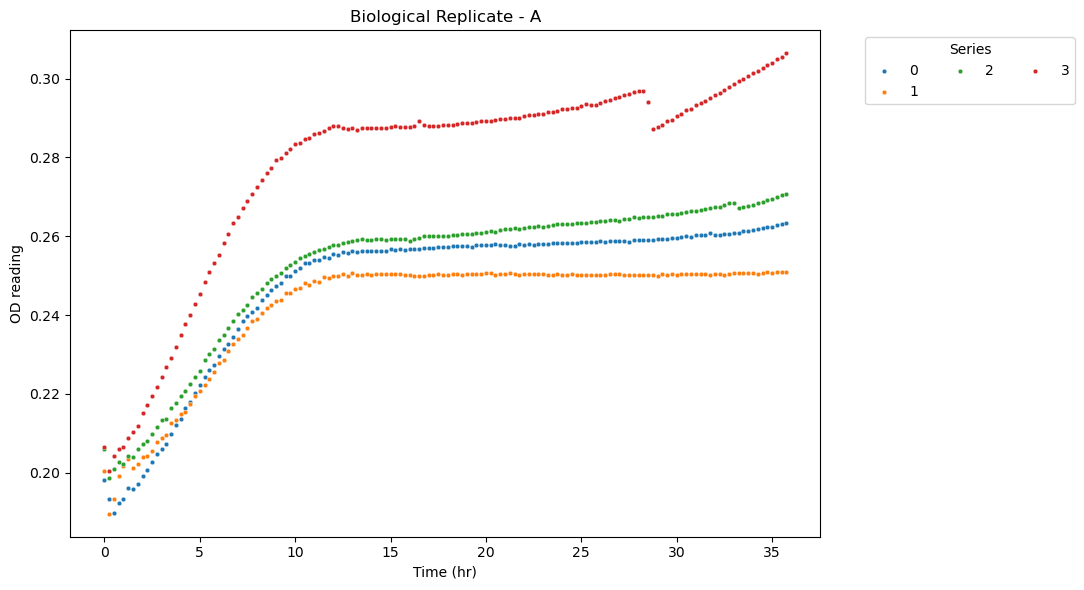

                  0         1         2         3
Time [s]                                         
0.000000   0.168667  0.185033  0.185867  0.184200
0.250028   0.171667  0.172600  0.177700  0.176567
0.500056   0.167400  0.173933  0.178767  0.179567
0.750083   0.176633  0.177233  0.181333  0.182833
1.000111   0.180767  0.181333  0.182433  0.185733
...             ...       ...       ...       ...
34.753333  0.222200  0.235633  0.236600  0.252800
35.003361  0.222200  0.235567  0.236500  0.252933
35.253389  0.222200  0.235433  0.236500  0.253433
35.503417  0.222133  0.235467  0.236433  0.253400
35.753444  0.222367  0.235567  0.236533  0.253733

[144 rows x 4 columns]


/var/folders/zr/1sf51yw57tz981pxfk3xyts40000gn/T/ipykernel_8657/3446414190.py:12: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  table_avg = table.groupby(np.arange(table.shape[1]) // col_num, axis=1).mean()


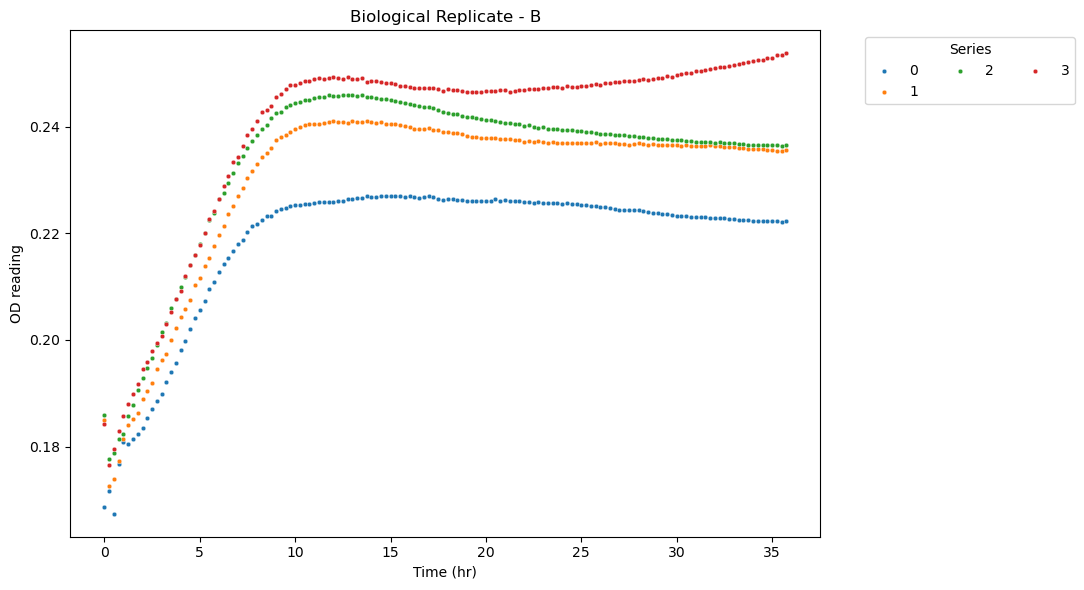

                  0         1         2         3
Time [s]                                         
0.000000   0.189567  0.193267  0.194000  0.187500
0.250028   0.174300  0.191267  0.186733  0.193333
0.500056   0.183800  0.190833  0.187900  0.199467
0.750083   0.191033  0.191600  0.189767  0.204333
1.000111   0.198367  0.194133  0.193867  0.204667
...             ...       ...       ...       ...
34.753333  0.331267  0.358000  0.351500  0.362900
35.003361  0.331633  0.358900  0.352500  0.363800
35.253389  0.332633  0.359933  0.353267  0.364633
35.503417  0.333133  0.360733  0.354233  0.365300
35.753444  0.334233  0.361733  0.355200  0.366267

[144 rows x 4 columns]


/var/folders/zr/1sf51yw57tz981pxfk3xyts40000gn/T/ipykernel_8657/3446414190.py:12: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  table_avg = table.groupby(np.arange(table.shape[1]) // col_num, axis=1).mean()


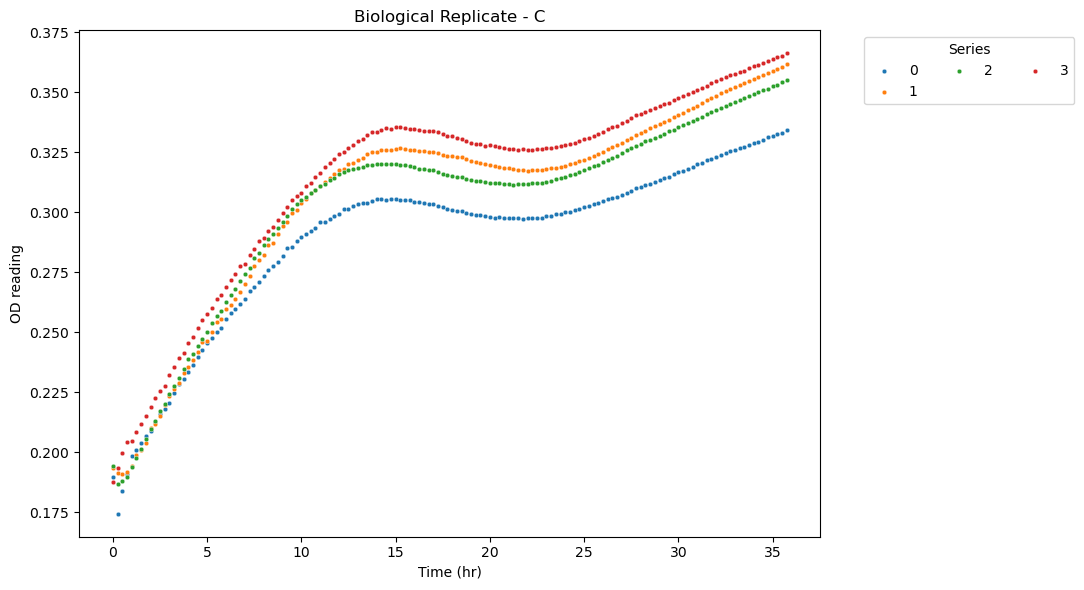

/var/folders/zr/1sf51yw57tz981pxfk3xyts40000gn/T/ipykernel_8657/3446414190.py:12: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  table_avg = table.groupby(np.arange(table.shape[1]) // col_num, axis=1).mean()


                  0         1         2         3
Time [s]                                         
0.000000   0.190467  0.194133  0.193467  0.210167
0.250028   0.179267  0.191833  0.188933  0.183633
0.500056   0.183900  0.192867  0.190333  0.187300
0.750083   0.187567  0.194033  0.191833  0.188367
1.000111   0.190433  0.196500  0.193967  0.189633
...             ...       ...       ...       ...
34.753333  0.251767  0.263067  0.270333  0.278067
35.003361  0.251600  0.262833  0.270333  0.278000
35.253389  0.251633  0.262933  0.270300  0.278033
35.503417  0.251467  0.262700  0.270367  0.278100
35.753444  0.251633  0.262867  0.270567  0.278000

[144 rows x 4 columns]


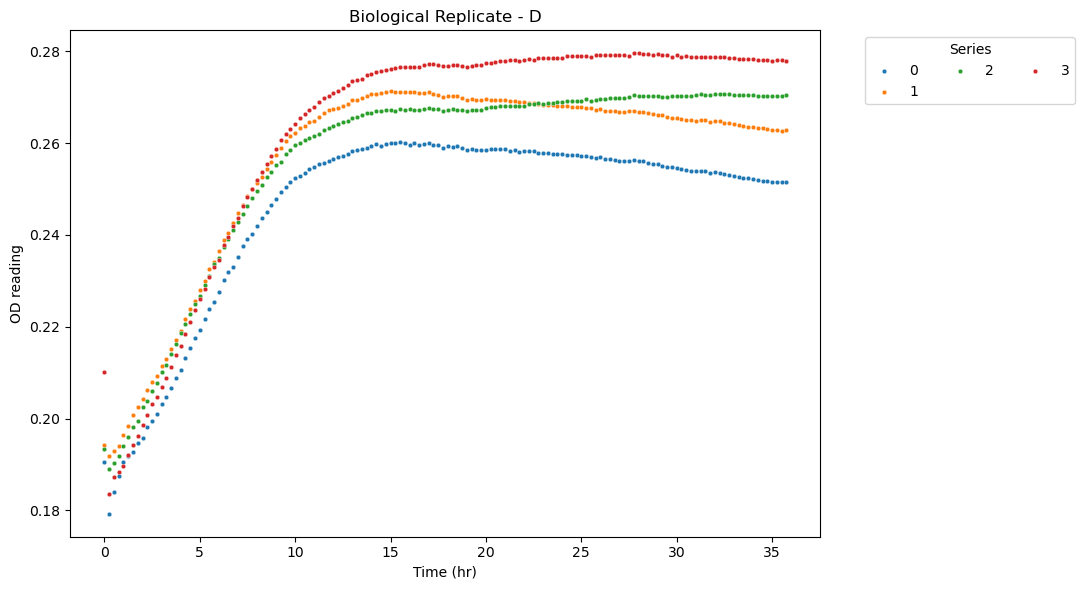

/var/folders/zr/1sf51yw57tz981pxfk3xyts40000gn/T/ipykernel_8657/3446414190.py:12: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  table_avg = table.groupby(np.arange(table.shape[1]) // col_num, axis=1).mean()


                  0         1         2         3
Time [s]                                         
0.000000   0.195367  0.202500  0.196800  0.202933
0.250028   0.192700  0.204000  0.198667  0.197667
0.500056   0.195300  0.204600  0.200533  0.199667
0.750083   0.197300  0.204700  0.201633  0.200200
1.000111   0.199567  0.207567  0.203700  0.200933
...             ...       ...       ...       ...
34.753333  0.268300  0.275333  0.273467  0.269567
35.003361  0.268067  0.275267  0.273300  0.269467
35.253389  0.268167  0.275100  0.273333  0.269533
35.503417  0.268067  0.275133  0.273267  0.269500
35.753444  0.268300  0.275333  0.273467  0.269700

[144 rows x 4 columns]


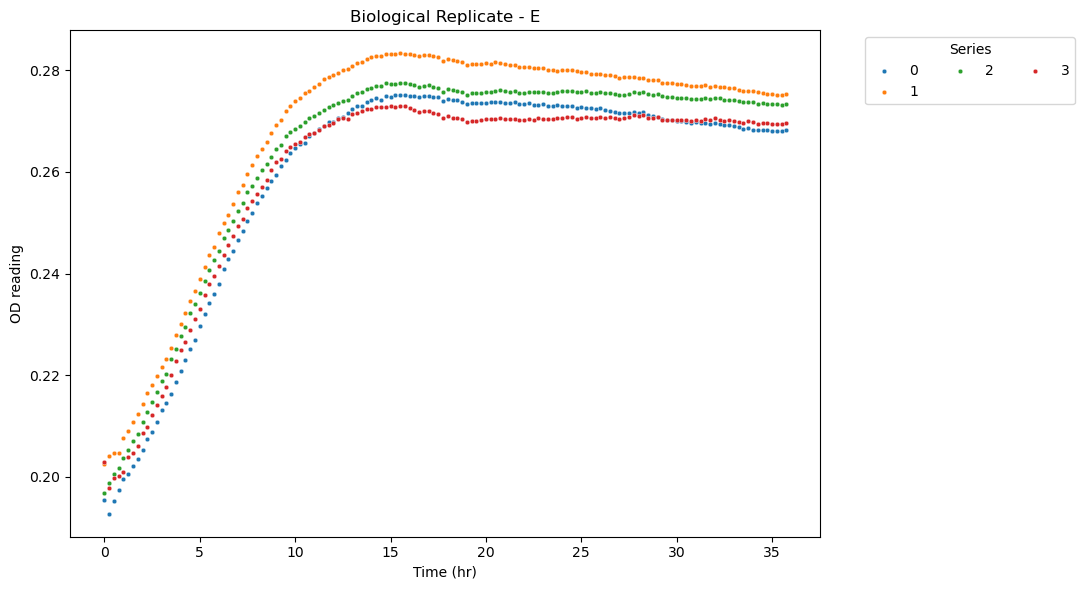

/var/folders/zr/1sf51yw57tz981pxfk3xyts40000gn/T/ipykernel_8657/3446414190.py:12: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  table_avg = table.groupby(np.arange(table.shape[1]) // col_num, axis=1).mean()


                  0         1         2         3
Time [s]                                         
0.000000   0.172900  0.187700  0.177533  0.186833
0.250028   0.175467  0.178700  0.177100  0.176667
0.500056   0.177933  0.180567  0.178833  0.181100
0.750083   0.179933  0.182033  0.180000  0.181700
1.000111   0.181600  0.183067  0.181733  0.183233
...             ...       ...       ...       ...
34.753333  0.238133  0.247900  0.260067  0.260400
35.003361  0.237867  0.247867  0.259900  0.260267
35.253389  0.238167  0.247967  0.260467  0.260533
35.503417  0.238200  0.248133  0.260600  0.260733
35.753444  0.238133  0.248267  0.260800  0.261000

[144 rows x 4 columns]


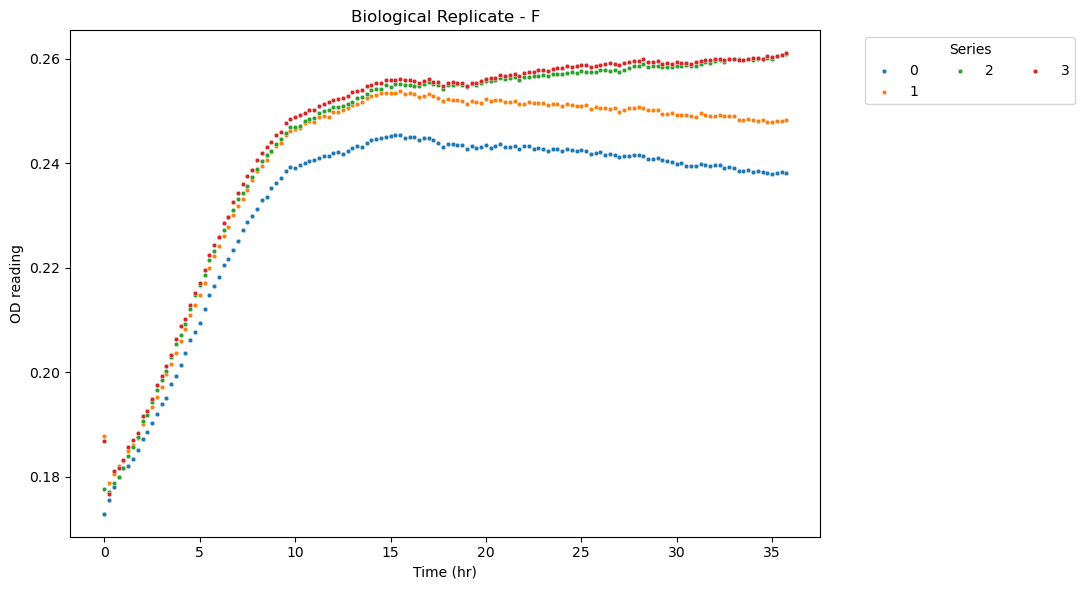

/var/folders/zr/1sf51yw57tz981pxfk3xyts40000gn/T/ipykernel_8657/3446414190.py:12: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  table_avg = table.groupby(np.arange(table.shape[1]) // col_num, axis=1).mean()


                  0         1         2         3
Time [s]                                         
0.000000   0.100400  0.101867  0.111467  0.119233
0.250028   0.102667  0.101133  0.101233  0.103533
0.500056   0.102633  0.100933  0.101033  0.103067
0.750083   0.102133  0.100233  0.100300  0.102600
1.000111   0.102300  0.100433  0.100500  0.102867
...             ...       ...       ...       ...
34.753333  0.101300  0.101833  0.099200  0.101467
35.003361  0.100967  0.101500  0.098900  0.101200
35.253389  0.101267  0.101700  0.099267  0.101567
35.503417  0.101467  0.101867  0.099433  0.101733
35.753444  0.101533  0.101833  0.099433  0.101667

[144 rows x 4 columns]


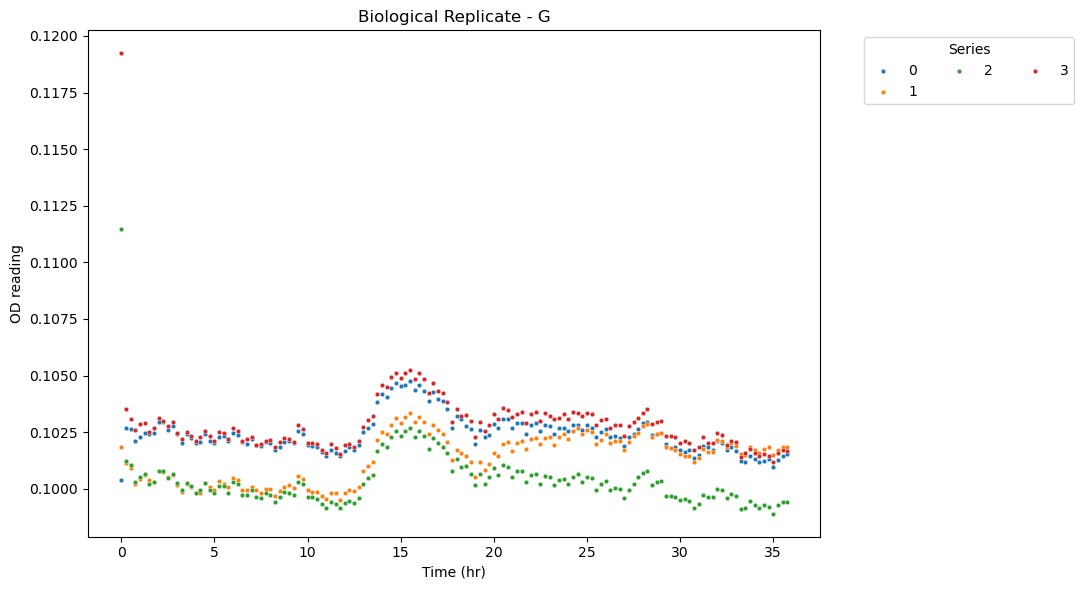

In [21]:
plot_biol_rep(df, num_bio_rep=8, col_num=3)

In [15]:
pfu_values = [0, 1e3, 1e5, 1e7]

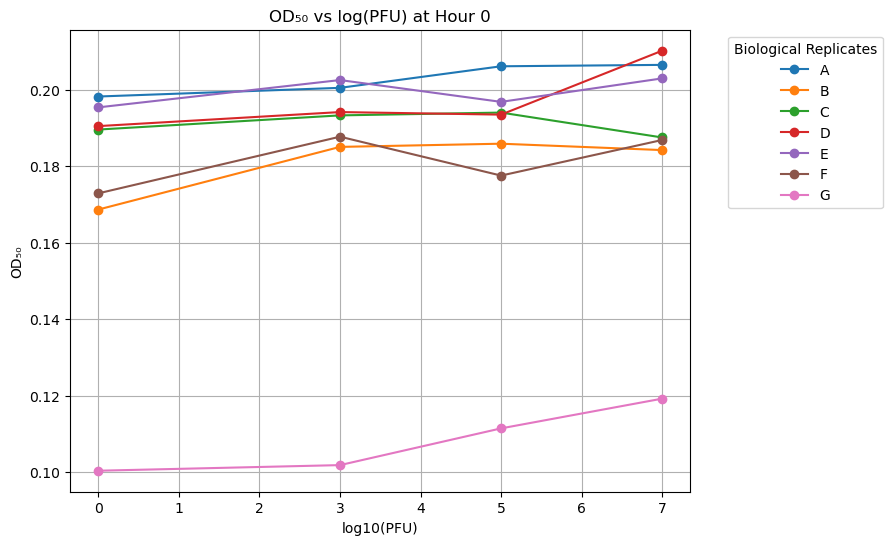

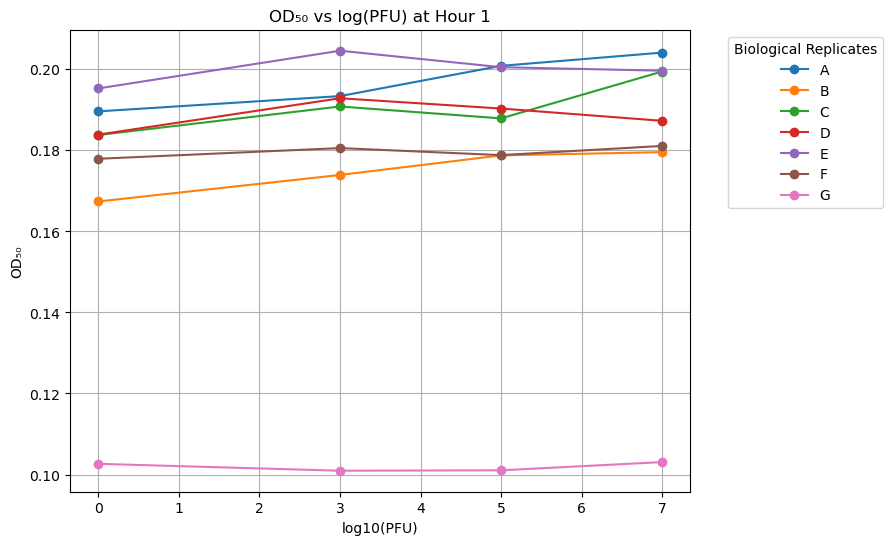

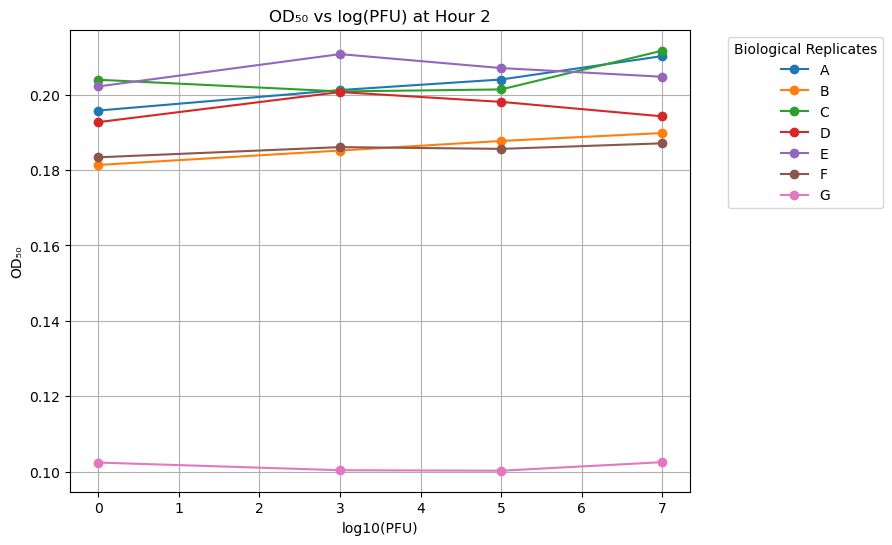

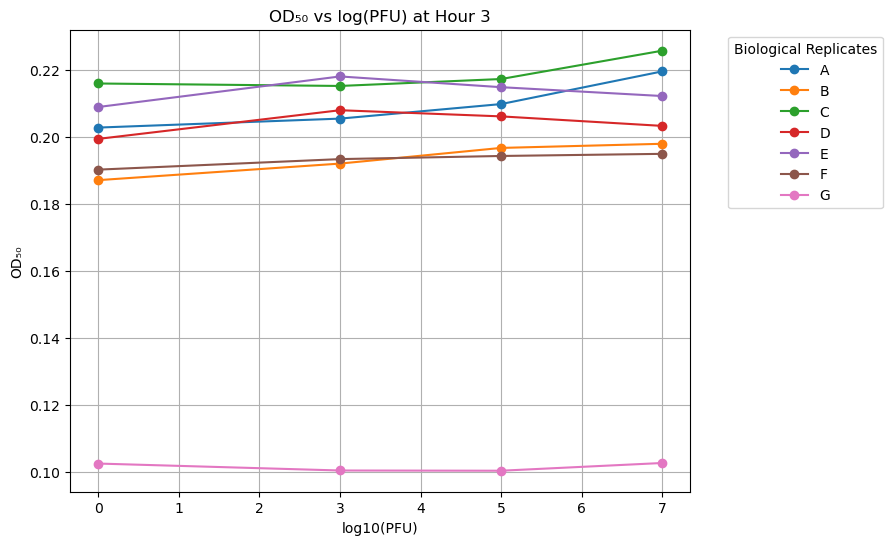

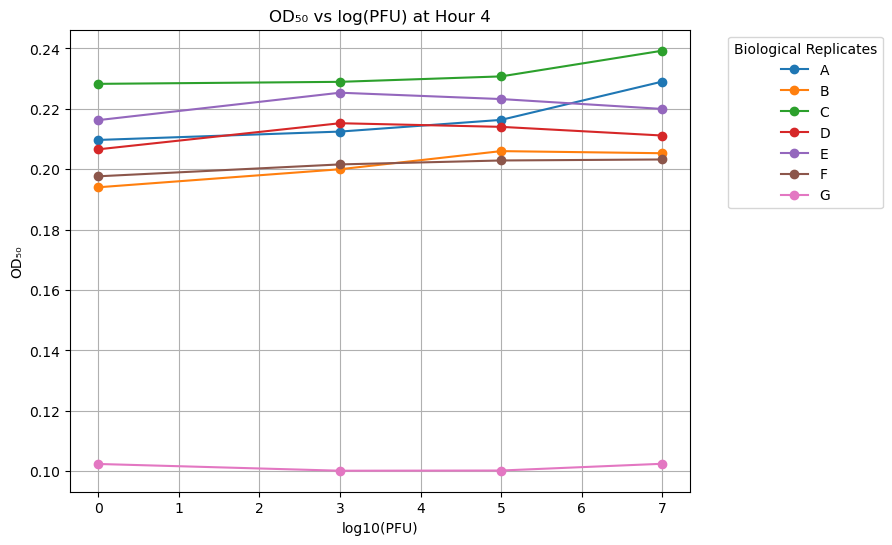

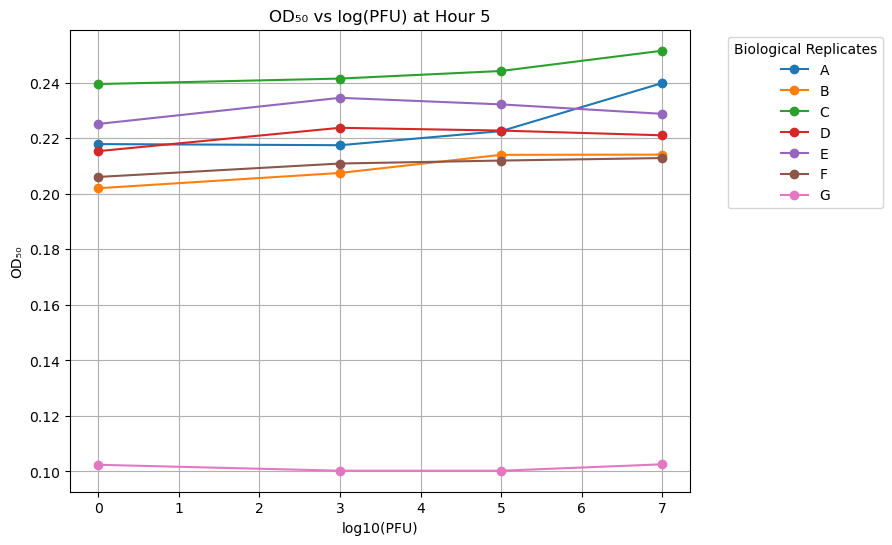

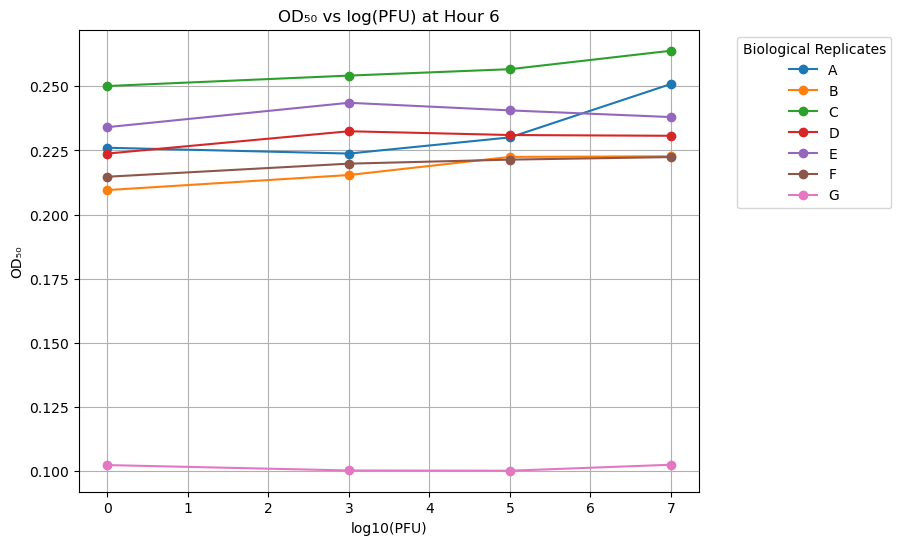

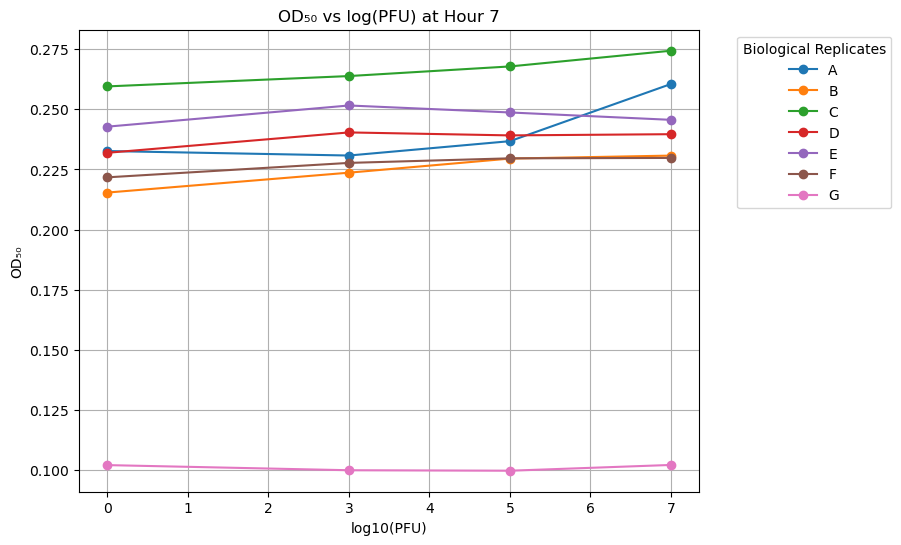

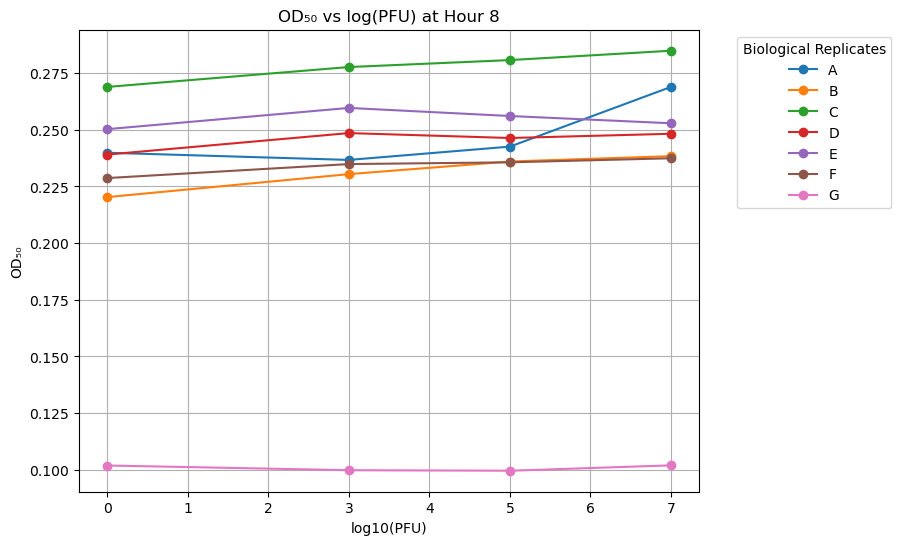

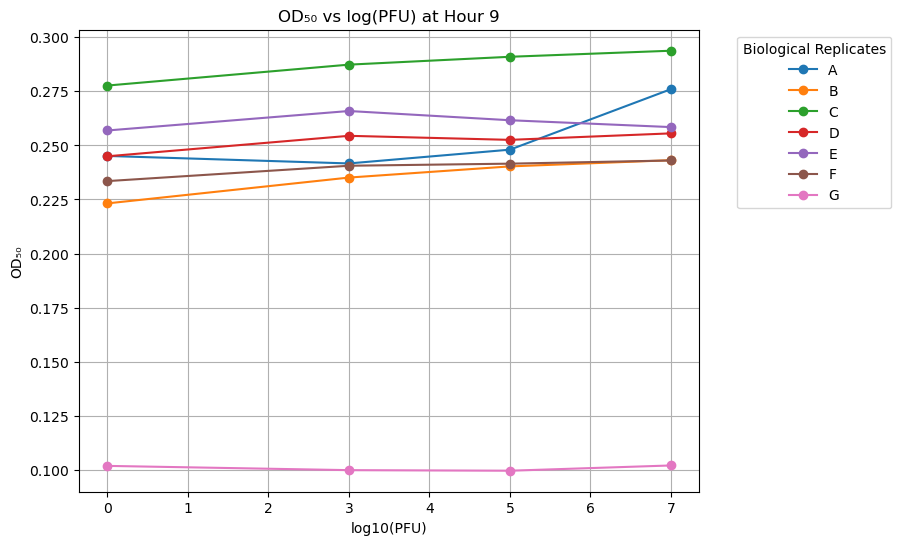

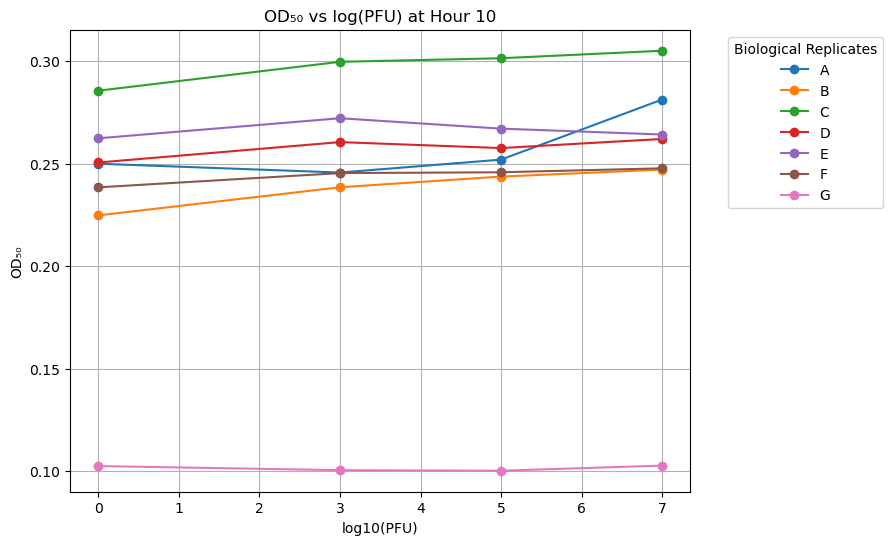

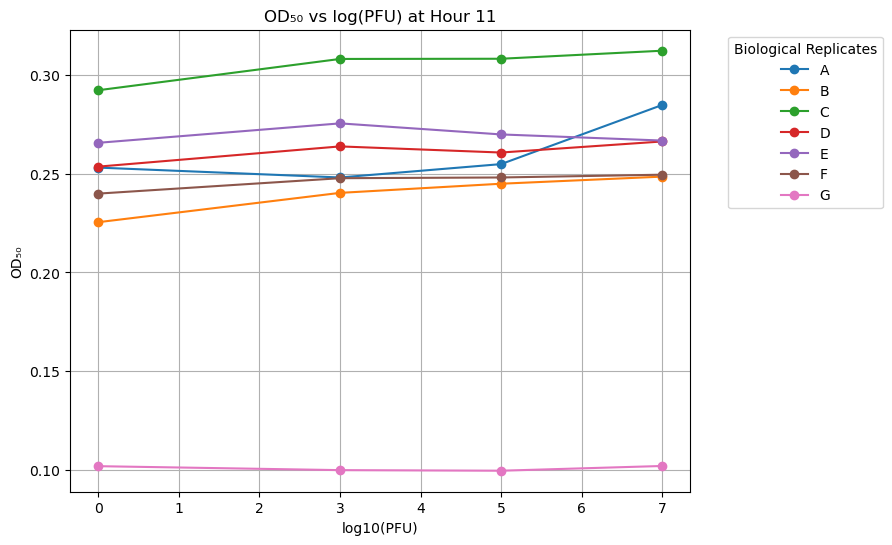

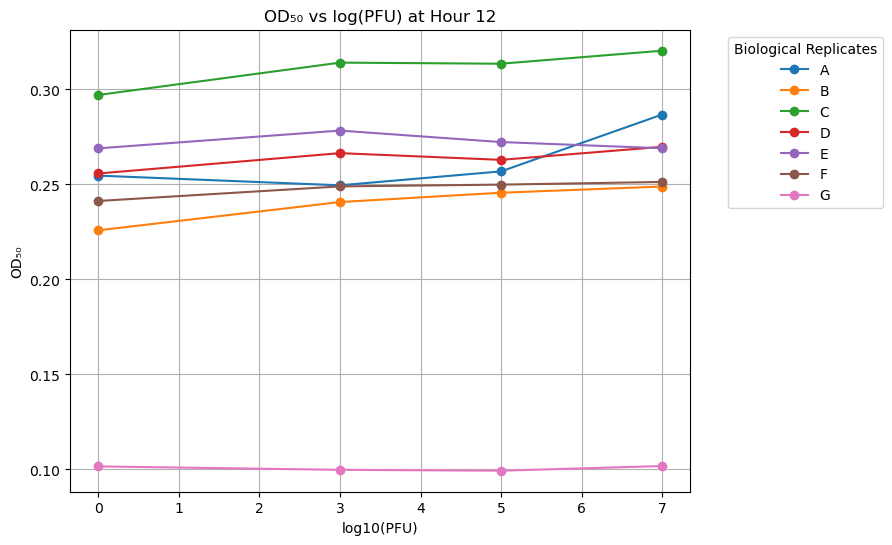

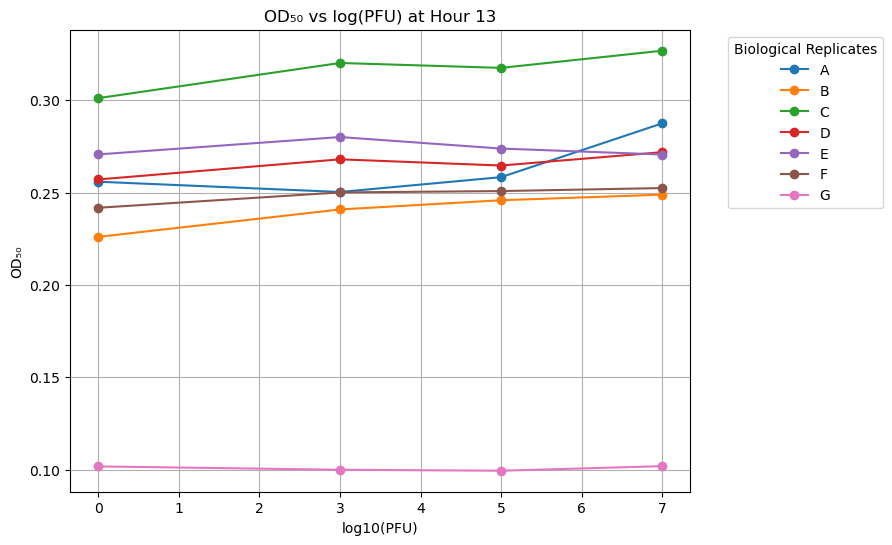

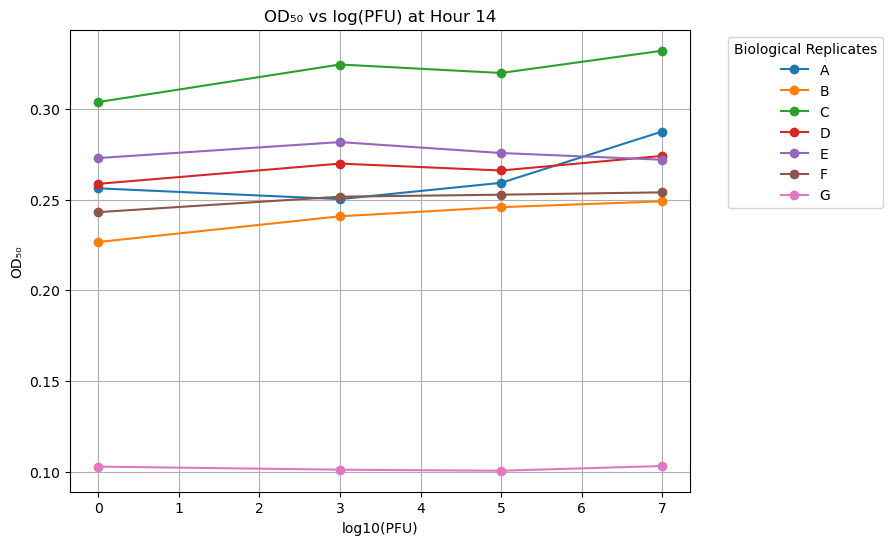

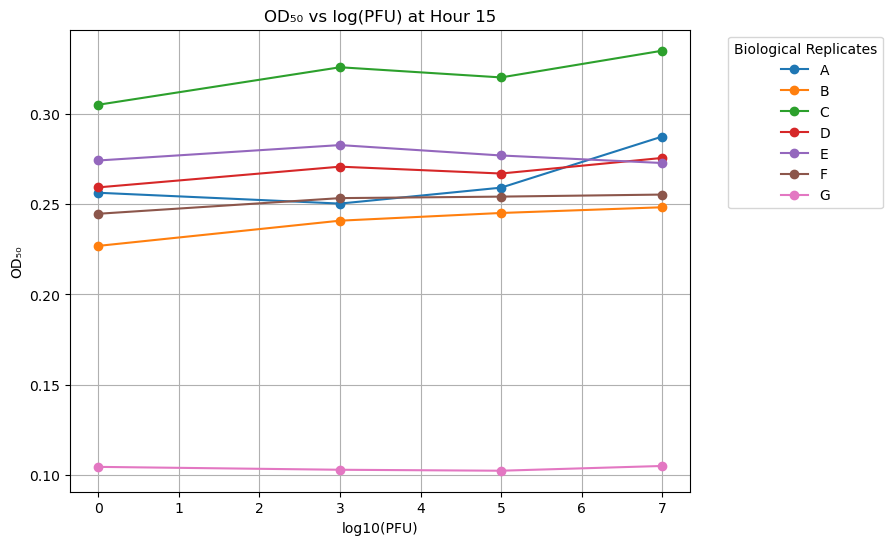

In [16]:
plot_dose_response(df1, pfu_values)